# Session 14 — The Same EEG Workflow, Now in Python
### NSBV BC2001 · 11 July 2026

In Session 13 you did all of this in MATLAB: describe data, run t-tests and ANOVA,
average across subjects, and make publication figures. **Today we rebuild the exact
same workflow in Python** — because most modern neuroscience labs use both.

Nothing here is new *statistics*. It is the same ideas with new tools:

| Job | MATLAB | Python |
|-----|--------|--------|
| Numeric arrays | built-in matrices | **NumPy** (`import numpy as np`) |
| Plots | `plot`, `imagesc` | **Matplotlib** (`import matplotlib.pyplot as plt`) |
| Stats tests | `ttest2`, `anova1` | **SciPy** (`from scipy import stats`) |
| Load `.mat` | `load` | `scipy.io.loadmat` |

> **One golden rule up front:** Python counts from **0**, MATLAB counts from **1**.
> `x[0]` is the first element in Python; `x(1)` is the first in MATLAB.

## 0. Setup
Run this first. If a package is missing, install it with `pip install numpy scipy matplotlib`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.io import loadmat

print('NumPy', np.__version__)

NumPy 2.2.6


## 1. NumPy arrays = MATLAB matrices

A NumPy **array** is Python's version of a MATLAB matrix. Watch the small syntax
differences — they cause 90% of beginner bugs.

In [2]:
# create arrays
v = np.array([2, 4, 6, 8, 10])        # a vector      (MATLAB: v = [2 4 6 8 10])
print('v          =', v)
print('v[0]       =', v[0], '  <-- FIRST element (0-based!)')
print('v[-1]      =', v[-1], '  <-- LAST element')
print('v[1:4]     =', v[1:4], '  <-- indices 1,2,3 (STOP is excluded)')

# handy constructors
print('arange     =', np.arange(0, 1, 0.25))   # like 0:0.25:1 but STOP excluded
print('linspace   =', np.linspace(0, 1, 5))    # 5 points from 0 to 1 (inclusive)
print('zeros      =', np.zeros(4))              # MATLAB: zeros(1,4)

v          = [ 2  4  6  8 10]
v[0]       = 2   <-- FIRST element (0-based!)
v[-1]      = 10   <-- LAST element
v[1:4]     = [4 6 8]   <-- indices 1,2,3 (STOP is excluded)
arange     = [0.   0.25 0.5  0.75]
linspace   = [0.   0.25 0.5  0.75 1.  ]
zeros      = [0. 0. 0. 0.]


### Vectorised maths and shapes
Like MATLAB, operations apply element-by-element — no loops needed.

In [3]:
x = np.array([1.0, 2.0, 3.0, 4.0])
print('x * 2      =', x * 2)
print('x ** 2     =', x ** 2)      # MATLAB: x.^2
print('mean/std   =', x.mean(), x.std(ddof=1))

M = np.array([[1, 2, 3],
              [4, 5, 6]])          # a 2 x 3 array
print('shape      =', M.shape)     # (rows, cols) -> (2, 3)
print('M[0, 2]    =', M[0, 2])     # row 0, col 2  (MATLAB: M(1,3))
print('column mean=', M.mean(axis=0))   # down the columns -> like mean(M,1)
print('row mean   =', M.mean(axis=1))   # along the rows   -> like mean(M,2)

x * 2      = [2. 4. 6. 8.]
x ** 2     = [ 1.  4.  9. 16.]
mean/std   = 2.5 1.2909944487358056
shape      = (2, 3)
M[0, 2]    = 3
column mean= [2.5 3.5 4.5]
row mean   = [2. 5.]


> **`axis` = MATLAB's dimension argument.** `axis=0` collapses rows (works *down
> the columns*, across subjects). `axis=1` collapses columns (*along a row*, within
> a subject). This is the Python version of `mean(X,1)` vs `mean(X,2)`.

## 2. Load the EEG data (`.mat` files)

We reuse the **same data files** from Session 13. `loadmat` returns a dictionary;
each variable comes back as a 2-D array, so we often `.ravel()` a saved row-vector
back into a flat 1-D array.

In [4]:
d = loadmat('../data/anova_data.mat')
print('keys:', [k for k in d if not k.startswith('__')])

control = d['control'].ravel()    # saved as (1, 16) -> flatten to (16,)
mild    = d['mild'].ravel()
severe  = d['severe'].ravel()
print('control n =', control.size, '| first 3 values:', control[:3].round(2))

keys: ['control', 'mild', 'severe', 'values', 'group', 'measure']
control n = 16 | first 3 values: [8.19 2.31 7.15]


## 3. Descriptive statistics

Same quantities as MATLAB — but note the **`ddof` trap**.

- MATLAB `std`/`var` divide by *n − 1* (the sample formula) **by default**.
- NumPy `std`/`var` divide by *n* by default. To match MATLAB you must pass
  **`ddof=1`**. Forgetting this is the most common MATLAB→Python discrepancy.

In [5]:
def describe(name, x):
    n = x.size
    print(f'{name:9s} n={n:2d}  mean={x.mean():6.2f}  '
          f'median={np.median(x):6.2f}  std={x.std(ddof=1):6.2f}  '
          f'SEM={x.std(ddof=1)/np.sqrt(n):6.2f}')

for nm, x in [('control', control), ('mild', mild), ('severe', severe)]:
    describe(nm, x)

control   n=16  mean=  6.31  median=  6.49  std=  1.39  SEM=  0.35
mild      n=16  mean=  5.11  median=  5.06  std=  1.38  SEM=  0.34
severe    n=16  mean=  2.96  median=  2.77  std=  0.85  SEM=  0.21


### Histogram + bar-with-error (Matplotlib)
Mirror of the MATLAB `histogram` and `bar`+`errorbar` figures.

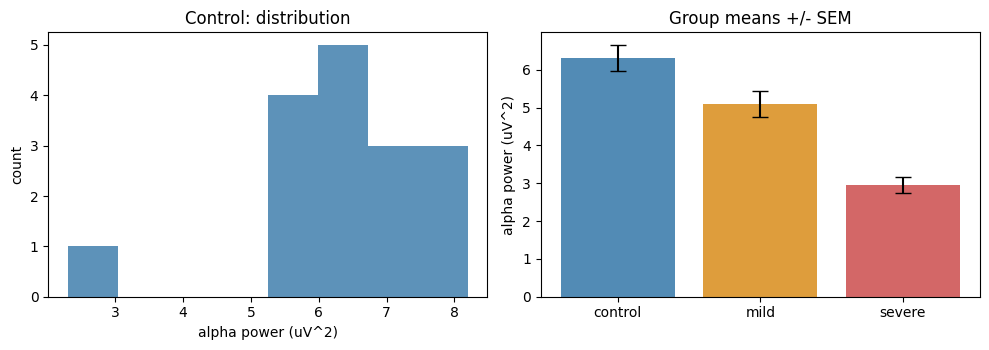

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

# histogram of one group
ax[0].hist(control, bins=8, color='#3477a8', alpha=0.8)
ax[0].set(title='Control: distribution', xlabel='alpha power (uV^2)', ylabel='count')

# bar chart of the three group means +/- SEM
groups = [control, mild, severe]
names  = ['control', 'mild', 'severe']
means  = [g.mean() for g in groups]
sems   = [g.std(ddof=1)/np.sqrt(g.size) for g in groups]
ax[1].bar(names, means, yerr=sems, capsize=6,
          color=['#3477a8', '#d98c1a', '#cc4c4c'], alpha=0.85)
ax[1].set(title='Group means +/- SEM', ylabel='alpha power (uV^2)')
plt.tight_layout(); plt.show()

## 4. t-tests in SciPy

| Question | MATLAB | SciPy |
|----------|--------|-------|
| One group vs a value | `ttest(x)` | `stats.ttest_1samp(x, 0)` |
| Two independent groups | `ttest2(a, b)` | `stats.ttest_ind(a, b)` |
| Paired / repeated | `ttest(before, after)` | `stats.ttest_rel(before, after)` |

In [7]:
# two independent groups: control vs severe
t, p = stats.ttest_ind(control, severe)
print(f'ttest_ind control vs severe:  t = {t:.2f}, p = {p:.3e}')

# one-sample: is control different from 0?
t1, p1 = stats.ttest_1samp(control, 0)
print(f'ttest_1samp control vs 0:     t = {t1:.2f}, p = {p1:.3e}')

ttest_ind control vs severe:  t = 8.25, p = 3.301e-09
ttest_1samp control vs 0:     t = 18.17, p = 1.263e-11


## 5. One-way ANOVA in SciPy

MATLAB's `anova1(values, group)` becomes `stats.f_oneway(g1, g2, g3, ...)` —
you pass each group as a separate argument (no group-label vector needed).

In [8]:
F, p = stats.f_oneway(control, mild, severe)
k = 3
N = control.size + mild.size + severe.size
print(f'ANOVA: F({k-1}, {N-k}) = {F:.2f}, p = {p:.3e}')
# compare to MATLAB Session 13: F(2,45) = 30.5, p ~ 4e-9  -- identical.

ANOVA: F(2, 45) = 30.51, p = 4.227e-09


### Post-hoc: which groups differ? (Tukey HSD)
MATLAB's `multcompare` lives in **statsmodels** in Python.
Install once with `pip install statsmodels` if needed.

In [9]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

values = np.concatenate([control, mild, severe])
labels = (['control'] * control.size + ['mild'] * mild.size + ['severe'] * severe.size)
print(pairwise_tukeyhsd(values, labels))
# 'reject = True' means that pair is significantly different (like multcompare).

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
 group1 group2 meandiff p-adj   lower   upper  reject
-----------------------------------------------------
control   mild  -1.2039 0.0219 -2.2588 -0.1491   True
control severe  -3.3556    0.0 -4.4105 -2.3007   True
   mild severe  -2.1517    0.0 -3.2065 -1.0968   True
-----------------------------------------------------


## 6. Multi-subject averaging & publication figure

Now the ERP workflow: load 20 subjects x time, average **across subjects**
(`axis=0`), add an SEM band with `fill_between`, and mark stimulus onset.

In [10]:
m = loadmat('../data/multisubject_erp.mat')
erp_std = m['erp_std']                 # shape (20, T) -- subjects x time
erp_tgt = m['erp_tgt']
time_ms = m['erp_time'].ravel() * 1000 # seconds -> ms
n_sub = erp_std.shape[0]
print('erp_std shape:', erp_std.shape, '(subjects x time)')

# grand average and SEM ACROSS subjects (axis=0)
ga_std,  ga_tgt  = erp_std.mean(axis=0),  erp_tgt.mean(axis=0)
sem_std = erp_std.std(axis=0, ddof=1) / np.sqrt(n_sub)
sem_tgt = erp_tgt.std(axis=0, ddof=1) / np.sqrt(n_sub)
print(f'grand-avg peak: standard = {ga_std.max():.2f} uV, target = {ga_tgt.max():.2f} uV')

erp_std shape: (20, 179) (subjects x time)
grand-avg peak: standard = 3.25 uV, target = 6.74 uV


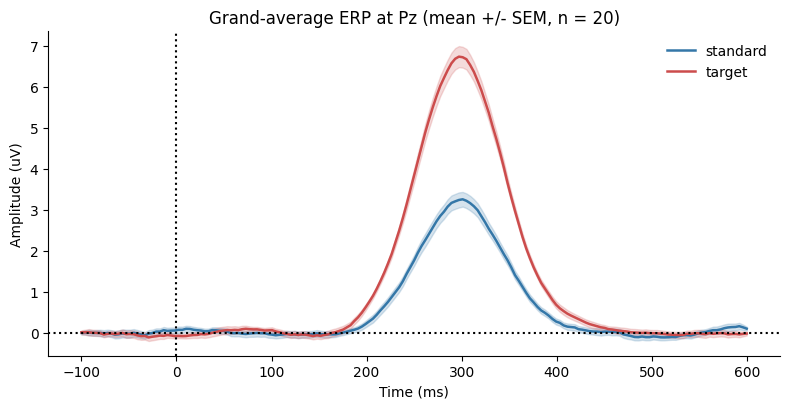

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for ga, sem, c, lab in [(ga_std, sem_std, '#3477a8', 'standard'),
                        (ga_tgt, sem_tgt, '#cc4c4c', 'target')]:
    ax.plot(time_ms, ga, color=c, lw=1.8, label=lab)
    ax.fill_between(time_ms, ga - sem, ga + sem, color=c, alpha=0.20)  # SEM band
ax.axvline(0, color='k', ls=':'); ax.axhline(0, color='k', ls=':')
ax.set(xlabel='Time (ms)', ylabel='Amplitude (uV)',
       title=f'Grand-average ERP at Pz (mean +/- SEM, n = {n_sub})')
ax.legend(frameon=False)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 7. Colour maps: the erp-image

MATLAB's `imagesc` + `colormap(parula)` becomes Matplotlib's `imshow`/`pcolormesh`
with a perceptually-uniform colormap like **`viridis`** (Python's default and a
close cousin of MATLAB's parula). Never use `jet`.

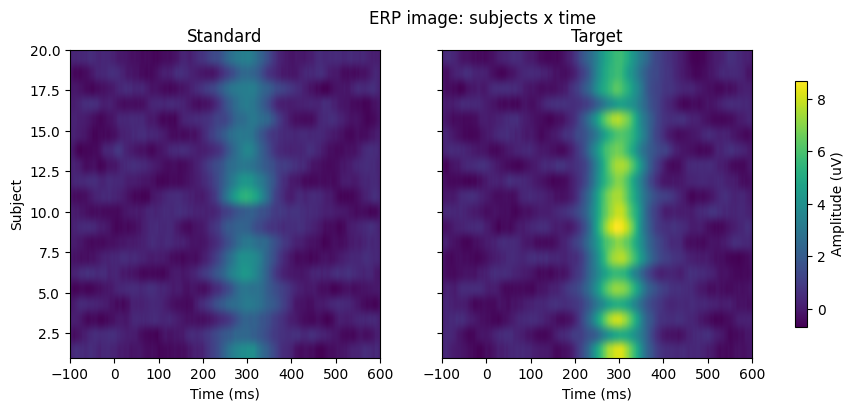

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
vmin = min(erp_std.min(), erp_tgt.min())    # ONE shared colour scale
vmax = max(erp_std.max(), erp_tgt.max())
for a, data, ttl in [(ax[0], erp_std, 'Standard'), (ax[1], erp_tgt, 'Target')]:
    im = a.imshow(data, aspect='auto', origin='lower', cmap='viridis',
                  vmin=vmin, vmax=vmax,
                  extent=[time_ms[0], time_ms[-1], 1, n_sub])
    a.set(xlabel='Time (ms)', title=ttl)
ax[0].set_ylabel('Subject')
fig.colorbar(im, ax=ax, label='Amplitude (uV)', shrink=0.8)
fig.suptitle('ERP image: subjects x time'); plt.show()

## 8. MATLAB → Python cheat sheet

| Task | MATLAB | Python (NumPy/SciPy/Matplotlib) |
|------|--------|--------------------------------|
| First element | `x(1)` | `x[0]` |
| Last element | `x(end)` | `x[-1]` |
| Range | `0:0.25:1` | `np.arange(0, 1.001, 0.25)` |
| Row vector of zeros | `zeros(1,n)` | `np.zeros(n)` |
| Element-wise power | `x.^2` | `x ** 2` |
| Sample std | `std(x)` | `x.std(ddof=1)` |
| Mean down columns | `mean(X,1)` | `X.mean(axis=0)` |
| Two-sample t-test | `ttest2(a,b)` | `stats.ttest_ind(a,b)` |
| One-way ANOVA | `anova1(v,g)` | `stats.f_oneway(g1,g2,g3)` |
| Post-hoc | `multcompare(s)` | `pairwise_tukeyhsd(v,labels)` |
| Line plot | `plot(x,y)` | `plt.plot(x,y)` |
| Shaded band | `fill(...)` | `plt.fill_between(...)` |
| Image / heatmap | `imagesc(M)` | `plt.imshow(M)` |
| Colormap | `colormap(parula)` | `cmap='viridis'` |

**Biggest gotchas:** 0-based indexing, `ddof=1` for sample std, and `axis=0` vs
`axis=1` for "across subjects" vs "within a subject".

## Exercises

Open `exercise_python.ipynb` and complete the three tasks:
1. Load `exercise_anova.mat` and run a one-way ANOVA on firing rate.
2. Load `exercise_figure.mat` and make a grand-average figure with SEM bands.
3. Load `homework_s13.mat` and reproduce your Session 13 homework result in Python.

A worked version is in `../solutions/exercise_python_SOLUTION.ipynb`.